<a href="https://colab.research.google.com/github/adljna/ProjectA-Group3-KematianAliKhamenei/blob/main/Data%20Integration/3_Merge_Preprocessing_Article.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Merge Article News**

Notebook ini menggabungkan beberapa file CSV menjadi satu file output.

## **(1) Konfigurasi**
Sesuaikan `csv_files` dan `output_file` sesuai kebutuhan.

In [1]:
import pandas as pd
import os

In [2]:
csv_files = [
    "content_articles_detik.csv",
    "content_articles_kompas.csv",
    "content_articles_tribun.csv",
    "content_articles_antara.csv",
    "content_articles_cnn.csv"
]

output_file = "merged_articles.csv"   # nama file output
add_source_column = True              # Tambahkan kembali variabel ini agar kolom 'News' ditambahkan

## **(2) Load & Preview Setiap File**

In [3]:
dfs = []
source_map = {
    "content_articles_detik": "Detik",
    "content_articles_kompas": "Kompas",
    "content_articles_tribun": "Tribun",
    "content_articles_antara": "Antara",
    "content_articles_cnn": "CNN"
}

for filepath in csv_files:
    if not os.path.exists(filepath):
        print(f"[WARNING] File tidak ditemukan: {filepath} — dilewati.")
        continue

    df = pd.read_csv(filepath)

    if add_source_column:
        # Ambil nama file tanpa ekstensi
        filename_base = os.path.splitext(os.path.basename(filepath))[0]
        # Dapatkan nama sumber dari mapping
        source_label = source_map.get(filename_base, "Unknown Source")
        df.insert(0, "News", source_label)

    dfs.append(df)
    print(f"✅ {filepath:45s} → {len(df):,} baris, {df.shape[1]} kolom")

print(f"\nTotal file berhasil dimuat: {len(dfs)}")

✅ content_articles_detik.csv                    → 100 baris, 4 kolom
✅ content_articles_kompas.csv                   → 100 baris, 4 kolom
✅ content_articles_tribun.csv                   → 100 baris, 4 kolom
✅ content_articles_antara.csv                   → 100 baris, 4 kolom
✅ content_articles_cnn.csv                      → 99 baris, 4 kolom

Total file berhasil dimuat: 5


## **(3) Merge Data**

In [4]:
if not dfs:
    raise ValueError("Tidak ada file yang berhasil dimuat. Periksa path file.")

merged = pd.concat(dfs, ignore_index=True)

merged.to_csv(output_file, index=False)

print(f"✅ File berhasil disimpan: {output_file}")
print(f"   Total baris  : {len(merged):,}")
print(f"   Total kolom  : {merged.shape[1]}")

✅ File berhasil disimpan: merged_articles.csv
   Total baris  : 499
   Total kolom  : 4


In [5]:
print("=== 5 Baris Pertama ===")
display(merged.head())

print("\n=== Info Kolom ===")
merged.info()

if add_source_column:
    print("\n=== Distribusi per Sumber (Kolom 'News') ===")
    display(merged["News"].value_counts().rename_axis("News").reset_index(name="jumlah_artikel"))

=== 5 Baris Pertama ===


,News,url,title,content
0,Detik,https://news.detik.com/berita/d-8392835/puan-b...,Puan Berduka Ali Khamenei Gugur Diserang AS-Is...,Ketua DPR RI Puan Maharani menyampaikan dukaci...
1,Detik,https://news.detik.com/internasional/d-8392814...,Trump Beri Sinyal Perang Lawan Iran Akan Selesai,Presiden Amerika Serikat (AS) Donald Trump men...
2,Detik,https://www.detik.com/bali/berita/d-8392847/pe...,Peringatan Keras Iran ke Kapal Tanker yang Nek...,\n Ilyas Fa...
3,Detik,https://finance.detik.com/energi/d-8392622/ira...,Iran Beri Peringatan Keras Kapal Tanker yang M...,"Juru Bicara Kementerian Luar Negeri Iran, Esma..."
4,Detik,https://finance.detik.com/energi/d-8392622/ira...,Iran Beri Peringatan Keras Kapal Tanker yang M...,"Juru Bicara Kementerian Luar Negeri Iran, Esma..."



=== Info Kolom ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 499 entries, 0 to 498
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   News     499 non-null    object
 1   url      499 non-null    object
 2   title    495 non-null    object
 3   content  491 non-null    object
dtypes: object(4)
memory usage: 15.7+ KB

=== Distribusi per Sumber (Kolom 'News') ===


,News,jumlah_artikel
0,Detik,100
1,Kompas,100
2,Tribun,100
3,Antara,100
4,CNN,99


# **Preproccessing Article News**

**(1) Instalasi Library**

Bagian ini berisi instalasi semua library Python yang dibutuhkan untuk preprocessing teks dan analisis sentimen.

In [6]:
# Library untuk NLP
!pip install polyglot icu pycld2 pyicu morfessor
!pip install deep-translator
!pip install Sastrawi
!pip install stanza
!pip install nltk
!pip install wordcloud

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.3/126.3 kB 4.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 268.2/268.2 kB 15.8 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.6/49.6 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 83.0 MB/s eta 0:00:00
  Created wheel for polyglot: filename=polyglot-16.7.4-py2.py3-none-any.whl size=52563 sha256=5b3a7a868d262ca9a1ff5ef345b0f2552f3d231271134be69404e794ec2c8d14
  Stored in directory: /root/.cache/pip/wheels/c7/5e/28/47349211ec1f91379f41ed10bc2520f7071ecfb6cbe182f6fe
  Created wheel for pyicu: filename=pyicu-2.16.2-cp312-cp312-linux_x86_64.whl size=2720231 sha256=e955002f2754dfc548f6d07ae16187a3d28d93231f2cd17a8c91e2d10abfa9c5
  Stored in directory: /root/.cache/pip/wheels/25/f3/cd/4923c874cedf8cdb860803

**(2) Impor Library**

Bagian ini mengimpor semua modul dan fungsi yang diperlukan dari library yang telah diinstal. Import dikelompokkan berdasarkan fungsinya.

In [7]:
# Standard Library
import io
import string
import re
import time
from collections import defaultdict, Counter

# Data Handling
import pandas as pd
import numpy as np

# (Opsional)
from google.colab import files

# NLP - NLTK
import nltk
from nltk.tokenize import word_tokenize
from nltk.probability import FreqDist

# NLP - Sastrawi
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory

# NLP - Stanza
import stanza

# Sentiment Analysis
from textblob import TextBlob
from deep_translator import GoogleTranslator

# Visualization
import matplotlib.pyplot as plt
from wordcloud import WordCloud

In [8]:
# Download NLTK data (if not already downloaded)
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('punkt_tab')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

**(3) Data Preprocessing**

Bagian ini membersihkan dan mempersiapkan teks dari artikel yang discrape untuk analisis lebih lanjut. Langkah-langkah meliputi:
- **`clean_text`**: Menghilangkan URL, mention, angka, tanda baca, dan spasi berlebih.
- **`tokenize_text`**: Memecah teks menjadi token kata.
- **`remove_stopwords`**: Menghapus kata-kata umum (stopwords) dalam bahasa Indonesia.
- **`stem_text`**: Melakukan stemming untuk mengembalikan kata ke bentuk dasar menggunakan `Sastrawi`.
- **Deteksi Bahasa**: Menggunakan `polyglot` untuk mendeteksi bahasa teks.

Library yang digunakan: `re`, `string`, `nltk`, `Sastrawi`, `polyglot`.

In [9]:
df_article = pd.read_csv('merged_articles.csv')
print("DataFrame 'df_article' berhasil dimuat dengan data dari 'merged_articles.csv'.")
print(f"Total baris: {len(df_article)}")
print(f"Total kolom: {df_article.shape[1]}")
print("Tampilan 5 baris pertama:")
display(df_article.head())

DataFrame 'df_article' berhasil dimuat dengan data dari 'merged_articles.csv'.
Total baris: 499
Total kolom: 4
Tampilan 5 baris pertama:


,News,url,title,content
0,Detik,https://news.detik.com/berita/d-8392835/puan-b...,Puan Berduka Ali Khamenei Gugur Diserang AS-Is...,Ketua DPR RI Puan Maharani menyampaikan dukaci...
1,Detik,https://news.detik.com/internasional/d-8392814...,Trump Beri Sinyal Perang Lawan Iran Akan Selesai,Presiden Amerika Serikat (AS) Donald Trump men...
2,Detik,https://www.detik.com/bali/berita/d-8392847/pe...,Peringatan Keras Iran ke Kapal Tanker yang Nek...,\n Ilyas Fa...
3,Detik,https://finance.detik.com/energi/d-8392622/ira...,Iran Beri Peringatan Keras Kapal Tanker yang M...,"Juru Bicara Kementerian Luar Negeri Iran, Esma..."
4,Detik,https://finance.detik.com/energi/d-8392622/ira...,Iran Beri Peringatan Keras Kapal Tanker yang M...,"Juru Bicara Kementerian Luar Negeri Iran, Esma..."


In [10]:
stemmer_factory = StemmerFactory()
stemmer = stemmer_factory.create_stemmer()

def clean_text(text):
    if not isinstance(text, str): # Handle non-string input, e.g., None
        return ""
    text = text.lower()
    text = re.sub(r'https?://\S+|www\.\S+', '', text) # Remove URLs
    text = re.sub(r'@\w+', '', text) # Remove mentions
    text = re.sub(r'\d+', '', text) # Remove numbers
    text = text.translate(str.maketrans('', '', string.punctuation)) # Remove punctuation
    text = re.sub(r'\s+', ' ', text).strip() # Remove extra spaces
    return text

def tokenize_text(text):
    if not isinstance(text, str): # Handle non-string input
        return []
    return word_tokenize(text)

# Get Indonesian stopwords
list_stopwords = nltk.corpus.stopwords.words('indonesian')

def remove_stopwords(tokens, stopwords_list):
    return [word for word in tokens if word not in stopwords_list and word.strip() != '']

def stem_text(tokens):
    return [stemmer.stem(word) for word in tokens]

In [11]:
# Terapkan cleaning dan tokenisasi
df_article['text_cleaned'] = df_article['content'].fillna('').apply(clean_text)
df_article['tokens'] = df_article['text_cleaned'].apply(tokenize_text)

# Hapus stopwords
df_article['tokens_no_stop'] = df_article['tokens'].apply(lambda x: remove_stopwords(x, list_stopwords))

# Lakukan stemming
df_article['tokens_stemmed'] = df_article['tokens_no_stop'].apply(stem_text)

# Gabungkan kembali token yang sudah di-stem menjadi string
df_article['text_final'] = df_article['tokens_stemmed'].apply(lambda x: ' '.join(x))

print("DataFrame setelah Cleaning, Tokenisasi, Stopword Removal, dan Stemming:")
print(df_article[['content', 'text_cleaned', 'tokens', 'tokens_no_stop', 'tokens_stemmed', 'text_final']].head())

# Language Detection (using Polyglot for demonstration, Stanza for POS Tagging)
print("\nDeteksi Bahasa pada Konten Asli:")
for index, row in df_article.head(5).iterrows(): # Check first 5 rows for language
    try:
        text = Text(row['content'] if pd.notna(row['content']) else "")
        if text.language.code:
            print(f"Row {index}: Language Detected: Code={text.language.code}, Name={text.language.name}")
        else:
            print(f"Row {index}: Language detection failed.")
    except Exception as e:
        print(f"Row {index}: Error during language detection - {e}")

DataFrame setelah Cleaning, Tokenisasi, Stopword Removal, dan Stemming:
                                             content  \
0  Ketua DPR RI Puan Maharani menyampaikan dukaci...   
1  Presiden Amerika Serikat (AS) Donald Trump men...   
2  \n                                    Ilyas Fa...   
3  Juru Bicara Kementerian Luar Negeri Iran, Esma...   
4  Juru Bicara Kementerian Luar Negeri Iran, Esma...   

                                        text_cleaned  \
0  ketua dpr ri puan maharani menyampaikan dukaci...   
1  presiden amerika serikat as donald trump menga...   
2  ilyas fadilah detikbali harga minyak dunia mel...   
3  juru bicara kementerian luar negeri iran esmai...   
4  juru bicara kementerian luar negeri iran esmai...   

                                              tokens  \
0  [ketua, dpr, ri, puan, maharani, menyampaikan,...   
1  [presiden, amerika, serikat, as, donald, trump...   
2  [ilyas, fadilah, detikbali, harga, minyak, dun...   
3  [juru, bicara, kementerian,

**(4) Analisis Sentimen**

Bagian ini menganalisis sentimen dari teks artikel. Karena `TextBlob` hanya mendukung bahasa Inggris, teks bahasa Indonesia akan diterjemahkan terlebih dahulu ke bahasa Inggris menggunakan `GoogleTranslator`, kemudian dianalisis polaritasnya. Teks panjang juga ditangani dengan memecahnya menjadi beberapa bagian untuk menghindari batasan API.

Library yang digunakan: `TextBlob`, `deep_translator`.

In [12]:
def analyze_long_text_sentiment(text):
    if not isinstance(text, str) or not text.strip():
        return pd.Series([None, None])

    # If text is short, directly process
    if len(text) < 4500:
        try:
            translated_text = GoogleTranslator(source='id', target='en').translate(text)
            blob = TextBlob(translated_text)
            return pd.Series([blob.sentiment.polarity, blob.sentiment.subjectivity])
        except Exception as e:
            print(f"Error processing short text: {e}")
            return pd.Series([None, None])

    # If text is long, chunk it
    else:
        try:
            max_chunk_size = 4500
            chunks = [text[i:i+max_chunk_size] for i in range(0, len(text), max_chunk_size)]

            translated_chunks = []
            for i, chunk in enumerate(chunks):
                # Add a small delay to avoid hitting API rate limits
                if i > 0: # Only sleep for subsequent chunks
                    time.sleep(0.5)
                translated_chunks.append(
                    GoogleTranslator(source='id', target='en').translate(chunk)
                )

            # Combine all translated chunks
            full_translated_text = ' '.join(translated_chunks)

            # Analyze sentiment of the full translated text
            blob = TextBlob(full_translated_text)
            return pd.Series([blob.sentiment.polarity, blob.sentiment.subjectivity])

        except Exception as e:
            print(f"Error processing long text: {e}")
            return pd.Series([None, None])

def get_sentiment_label_from_polarity(polarity):
    if polarity is None:
        return 'Undefined'
    elif polarity > 0.05:
        return 'Positive'
    elif polarity < -0.05:
        return 'Negative'
    else:
        return 'Netral'

# Apply the sentiment analysis function to the 'text_final' column
df_article[['polarity', 'subjectivity']] = df_article['text_final'].apply(analyze_long_text_sentiment)

# Fill any NaN polarity values with 0 before labeling
df_article['polarity'].fillna(0, inplace=True)

# Create sentiment labels
df_article['sentiment_label'] = df_article['polarity'].apply(get_sentiment_label_from_polarity)

print("\nDataFrame dengan hasil sentimen:")
print(df_article[['content', 'text_final', 'polarity', 'subjectivity', 'sentiment_label']].head())


DataFrame dengan hasil sentimen:
                                             content  \
0  Ketua DPR RI Puan Maharani menyampaikan dukaci...   
1  Presiden Amerika Serikat (AS) Donald Trump men...   
2  \n                                    Ilyas Fa...   
3  Juru Bicara Kementerian Luar Negeri Iran, Esma...   
4  Juru Bicara Kementerian Luar Negeri Iran, Esma...   

                                          text_final  polarity  subjectivity  \
0  ketua dpr ri puan maharani dukacita masyarakat...  0.014035      0.185965   
1  presiden amerika serikat as donald trump peran... -0.033333      0.200000   
2  ilyas fadilah detikbali harga minyak dunia lon...  0.061053      0.470526   
3  juru bicara menteri negeri iran esmail baghaei...  0.004545      0.414773   
4  juru bicara menteri negeri iran esmail baghaei...  0.004545      0.414773   

  sentiment_label  
0          Netral  
1          Netral  
2        Positive  
3          Netral  
4          Netral  


/tmp/ipykernel_4899/502083443.py:55: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_article['polarity'].fillna(0, inplace=True)



=== Distribusi Sentimen ===


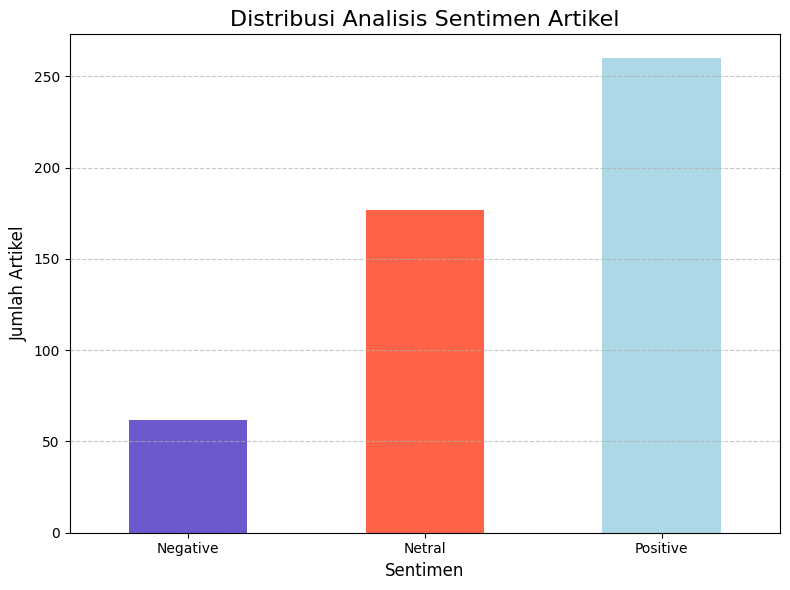

,Jumlah Artikel
sentiment_label,
Negative,62
Netral,177
Positive,260


In [13]:
print("\n=== Distribusi Sentimen ===")
sentiment_counts = df_article['sentiment_label'].value_counts().sort_index()

plt.figure(figsize=(8, 6))
sentiment_counts.plot(kind='bar', color=['#6A5ACD', '#FF6347', '#ADD8E6'])
plt.title('Distribusi Analisis Sentimen Artikel', fontsize=16)
plt.xlabel('Sentimen', fontsize=12)
plt.ylabel('Jumlah Artikel', fontsize=12)
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

display(sentiment_counts.to_frame(name='Jumlah Artikel'))

**(5) Visualisasi (Word Cloud)**

Bagian ini membuat visualisasi Word Cloud untuk kata-kata yang paling sering muncul dalam artikel dengan sentimen Positif dan Negatif. Ini membantu dalam memahami topik yang terkait dengan masing-masing sentimen.

Library yang digunakan: `matplotlib.pyplot`, `wordcloud`.


Jumlah artikel Positif: 260
Jumlah artikel Negatif: 62


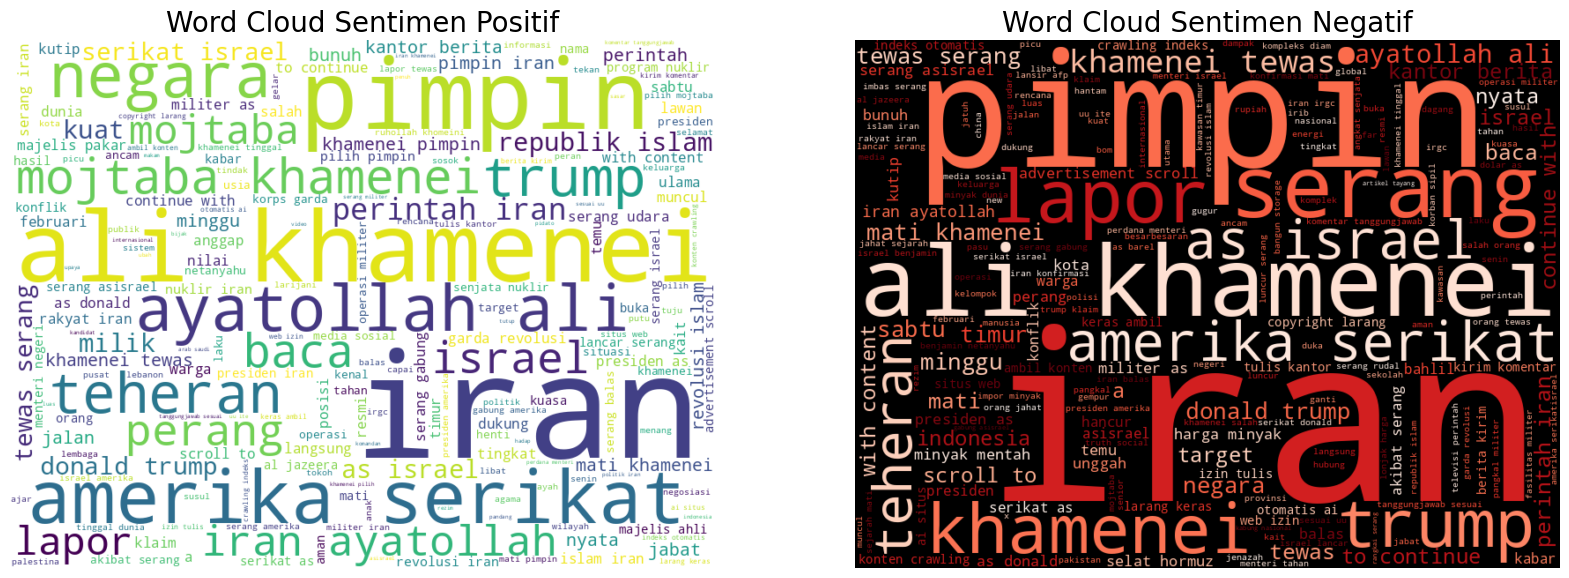

In [14]:
positive_articles_df = df_article[df_article['sentiment_label'] == 'Positive']
negative_articles_df = df_article[df_article['sentiment_label'] == 'Negative']

print(f"\nJumlah artikel Positif: {len(positive_articles_df)}")
print(f"Jumlah artikel Negatif: {len(negative_articles_df)}")

positive_text = ' '.join(positive_articles_df['text_final'])
negative_text = ' '.join(negative_articles_df['text_final'])

plt.figure(figsize=(20, 10))

# Word Cloud Positif
if positive_text:
    plt.subplot(1, 2, 1)
    wordcloud_positive = WordCloud(
        stopwords=list_stopwords,
        width=800,
        height=600,
        background_color='white',
        colormap='viridis'
    ).generate(positive_text)
    plt.imshow(wordcloud_positive, interpolation='bilinear')
    plt.title('Word Cloud Sentimen Positif', fontsize=20)
    plt.axis('off')
else:
    print("Tidak ada teks positif untuk Word Cloud.")

# Word Cloud Negatif
if negative_text:
    plt.subplot(1, 2, 2)
    wordcloud_negative = WordCloud(
        stopwords=list_stopwords,
        width=800,
        height=600,
        background_color='black',
        colormap='Reds'
    ).generate(negative_text)
    plt.imshow(wordcloud_negative, interpolation='bilinear')
    plt.title('Word Cloud Sentimen Negatif', fontsize=20)
    plt.axis('off')
else:
    print("Tidak ada teks negatif untuk Word Cloud.")

plt.show()

**(6) Ekspor Hasil**

Bagian ini menyimpan DataFrame akhir yang berisi semua data, hasil preprocessing, dan sentimen ke dalam file CSV.

In [15]:
df_article.to_csv(r'analyzed_merged_articles.csv', index=False)
print("Hasil analisis disimpan ke 'analyzed_merged_articles.csv'")

Hasil analisis disimpan ke 'analyzed_merged_articles.csv'
